# PART 1 : Basic Exploration Questions

## Q1: Load and inspect the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [71]:
sns.set_style('darkgrid')

Now we can load the data set and inspect it

In [2]:
smartphone_df = pd.read_csv('Smartphone_Usage_Productivity_Dataset_50000.csv')
smartphone_df

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U49996,44,Male,Business Owner,Android,5.9,5.4,5,6.6,1,11,5,3.0
49996,U49997,42,Other,Business Owner,Android,2.9,7.4,9,6.3,2,20,4,6.2
49997,U49998,27,Female,Freelancer,iOS,1.4,2.5,4,6.7,9,39,4,5.1
49998,U49999,41,Female,Business Owner,iOS,8.9,3.0,6,5.5,2,51,0,9.2


In [ ]:
sns.scatterplot(x='Stress_Level', y='Work_Productivity_Score', hue=smartphone_df.Gender, data=smartphone_df);

In [ ]:
smartphone_df.Gender

In [ ]:
smartphone_df.Gender.unique()

We can get some more information about the data set using `info` method. We can also get some statistical information about numerics in the data set using `describe` method.

In [ ]:
smartphone_df.info()

In [ ]:
smartphone_df.describe()

# Q2: How many users and what's the gender distribution?

In [ ]:
# Count users
print(f"Total users: {len(smartphone_df)}")

In [ ]:
smartphone_df['Gender'].value_counts()

In [4]:
# Gender distribution
gender_counts = smartphone_df["Gender"].value_counts()
gender_counts

Gender
Male      16708
Female    16679
Other     16613
Name: count, dtype: int64

In [ ]:
type(gender_counts)

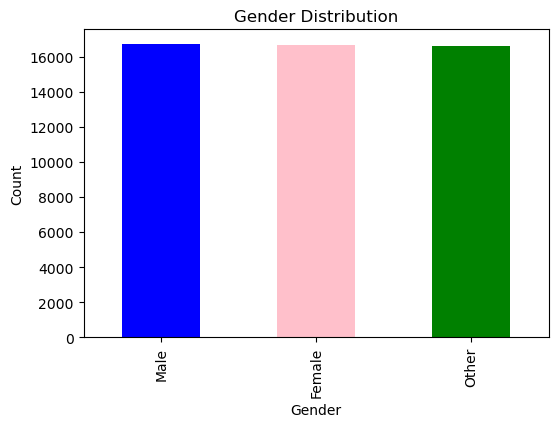

In [5]:
# plot pie chart
plt.figure(figsize=(6,4))
gender_counts.plot(kind='bar', color=['blue', 'pink', 'green'])
plt.title("Gender Distribution");
plt.xlabel("Gender")
plt.ylabel("Count");

# Part 2: Univariate Analysis

## Q3: Distribution of Daily Phone Usage

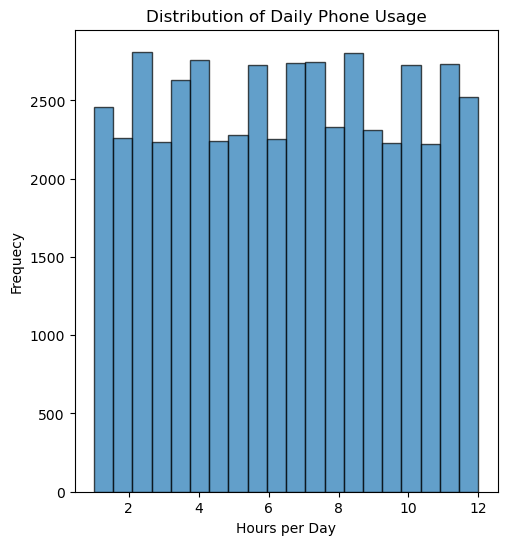

In [6]:
plt.figure(figsize=(12,6))

# Histigram
plt.subplot(1, 2, 1)
plt.hist(smartphone_df['Daily_Phone_Hours'], bins=20, edgecolor='black', alpha=0.7) # alpha=0.7 controls the transparency/opacity of a plot element
plt.xlabel('Hours per Day')
plt.ylabel('Frequecy')
plt.title('Distribution of Daily Phone Usage');

In [7]:
smartphone_df['Daily_Phone_Hours'].describe()

count    50000.000000
mean         6.509116
std          3.170903
min          1.000000
25%          3.800000
50%          6.500000
75%          9.200000
max         12.000000
Name: Daily_Phone_Hours, dtype: float64

In [ ]:
# Box plot
plt.subplot(1, 2, 2)
plt.boxplot(smartphone_df['Daily_Phone_Hours'])
plt.ylabel('Hours')
plt.title('Box Plot of Phone Usage');

In [8]:
smartphone_df.sample(5)[['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type']]

,User_ID,Age,Gender,Occupation,Device_Type
24637,U24638,57,Other,Professional,iOS
21876,U21877,51,Female,Student,Android
18600,U18601,20,Female,Business Owner,Android
4542,U4543,37,Other,Professional,Android
49809,U49810,38,Other,Freelancer,iOS


In [9]:
print(f"Average daily phone usage: {smartphone_df['Daily_Phone_Hours'].mean():.2f} hours.")
print(f"Min: {smartphone_df['Daily_Phone_Hours'].min()}, Max: {smartphone_df['Daily_Phone_Hours'].max()}.")

Average daily phone usage: 6.51 hours.
Min: 1.0, Max: 12.0.


In [ ]:
smartphone_df.Stress_Level.plot()

## Q4: Stress Level Distribution

In the Stress Level series, the values are 1 - 10, of which the value counts of each can be obtained using `value_counts` methond and sorted using `sort_values` method.

In [18]:
stress_counts = smartphone_df['Stress_Level'].value_counts().sort_values()

In [19]:
stress_counts

Stress_Level
4     4871
7     4933
1     4940
9     4993
8     4993
3     5009
10    5031
2     5058
6     5076
5     5096
Name: count, dtype: int64

In [20]:
type(stress_counts)

pandas.core.series.Series

Now I can plot the stress levels.

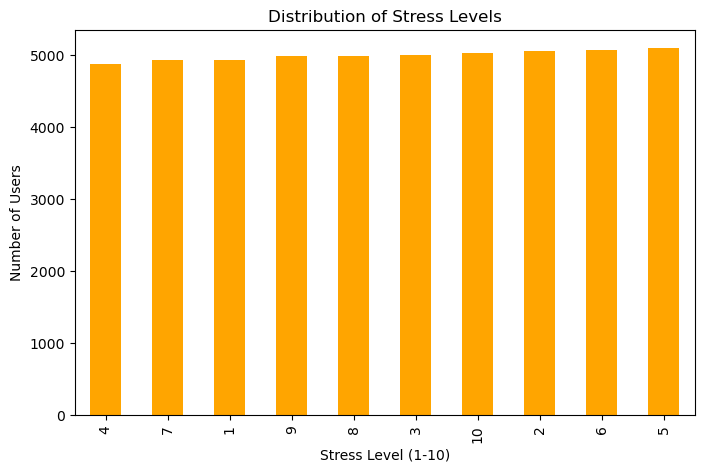

In [21]:
plt.figure(figsize=(8, 5))
stress_counts.plot(kind='bar', color='orange')
plt.xlabel('Stress Level (1-10)')
plt.ylabel('Number of Users')
plt.title('Distribution of Stress Levels');

In [24]:
# idxmax - returns index with max value
print(f"Most common stress level: {stress_counts.idxmax()}")
print(f"Least common stress level: {stress_counts.idxmin()}")

Most common stress level: 5
Least common stress level: 4


In [25]:
smartphone_df['Stress_Level'].value_counts().sort_index()

Stress_Level
1     4940
2     5058
3     5009
4     4871
5     5096
6     5076
7     4933
8     4993
9     4993
10    5031
Name: count, dtype: int64

In [26]:
# Returns information about the entire data frame
smartphone_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    50000 non-null  object 
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  object 
 3   Occupation                 50000 non-null  object 
 4   Device_Type                50000 non-null  object 
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               50000 non-null  int64  
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usag

In [27]:
smartphone_df.describe()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.504500,32.43898,3.004580,8.006844
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871095,16.12151,1.996657,3.461300
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000


In [28]:
smartphone_df

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U49996,44,Male,Business Owner,Android,5.9,5.4,5,6.6,1,11,5,3.0
49996,U49997,42,Other,Business Owner,Android,2.9,7.4,9,6.3,2,20,4,6.2
49997,U49998,27,Female,Freelancer,iOS,1.4,2.5,4,6.7,9,39,4,5.1
49998,U49999,41,Female,Business Owner,iOS,8.9,3.0,6,5.5,2,51,0,9.2


In [32]:
smartphone_df['Device_Type'].unique()

array(['Android', 'iOS'], dtype=object)

In [33]:
gender_device_counts = smartphone_df.groupby('Device_Type')['Gender'].value_counts()
gender_device_counts

Device_Type  Gender
Android      Male      8449
             Female    8374
             Other     8257
iOS          Other     8356
             Female    8305
             Male      8259
Name: count, dtype: int64

In [39]:
type(smartphone_df.groupby(['Device_Type', 'Gender', 'Age'])['Occupation'].value_counts())

pandas.core.series.Series

In [37]:
device_df = smartphone_df.groupby(['Device_Type', 'Gender'])['Daily_Phone_Hours'].mean()
device_df

Device_Type  Gender
Android      Female    6.521794
             Male      6.534975
             Other     6.534734
iOS          Female    6.498085
             Male      6.510134
             Other     6.454907
Name: Daily_Phone_Hours, dtype: float64

In [38]:
type(device_df)

pandas.core.series.Series

# PART 3: Bivariate Analysis
## Q5: Relationship between Phone Usage and Sleep Hours

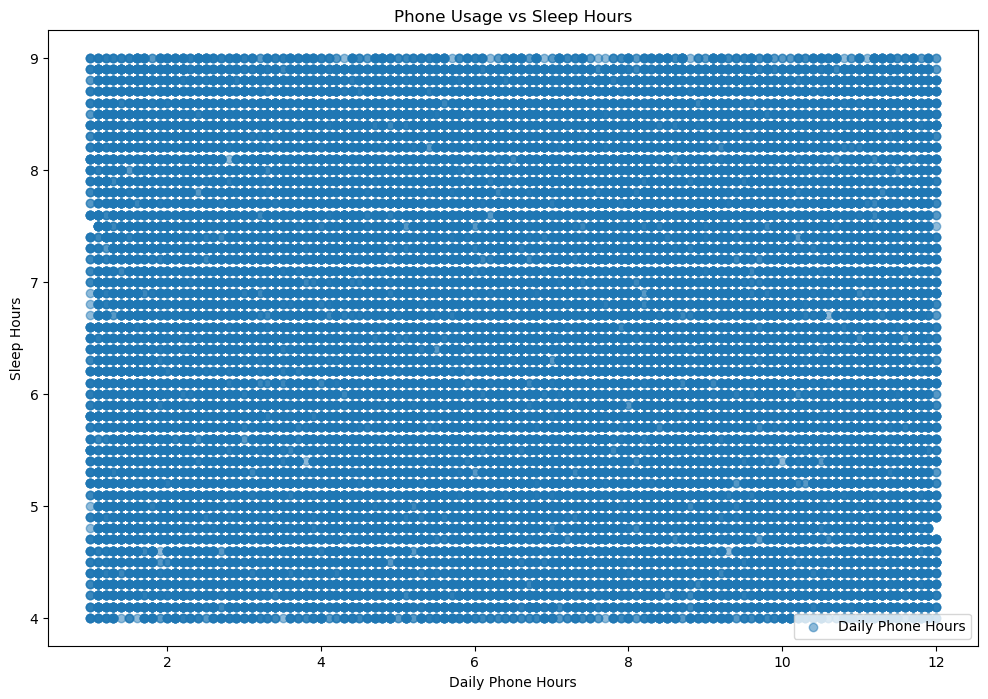

In [40]:
plt.figure(figsize=(12,8))
plt.scatter(x=smartphone_df['Daily_Phone_Hours'], y=smartphone_df['Sleep_Hours'], alpha=0.5)
plt.xlabel('Daily Phone Hours')
plt.ylabel('Sleep Hours')
plt.legend(['Daily Phone Hours', 'Sleep Hours'])
plt.title('Phone Usage vs Sleep Hours');

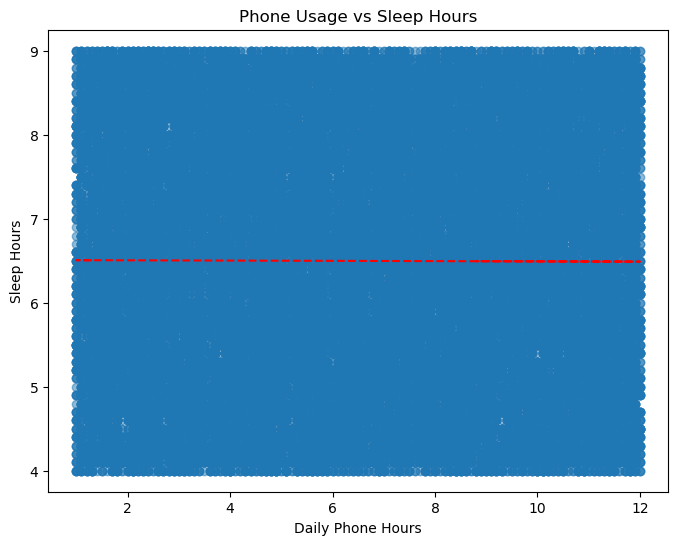

Correlation: -0.00


In [41]:
plt.figure(figsize=(8,6))
plt.scatter(x=smartphone_df['Daily_Phone_Hours'], y=smartphone_df['Sleep_Hours'], alpha=0.5)
plt.xlabel('Daily Phone Hours')
plt.ylabel('Sleep Hours')
plt.title('Phone Usage vs Sleep Hours')

# Add trend line
z = np.polyfit(smartphone_df['Daily_Phone_Hours'], smartphone_df['Sleep_Hours'], 1)
p = np.poly1d(z)
plt.plot(smartphone_df['Daily_Phone_Hours'], p(smartphone_df['Daily_Phone_Hours']), 'r--')

plt.show()

# Correlation
correlation = smartphone_df['Daily_Phone_Hours'].corr(smartphone_df['Sleep_Hours'])
print(f"Correlation: {correlation:.2f}")

## Q6: Gender differences in phone usage

In [ ]:
smartphone_df.sample(5)

In [42]:
gender_usage = smartphone_df.groupby('Gender')['Daily_Phone_Hours'].agg(['mean', 'median', 'std'])
gender_usage

,mean,median,std
Gender,,,
Female,6.509989,6.5,3.156152
Male,6.522696,6.5,3.173798
Other,6.494583,6.5,3.182871


In [43]:
type(gender_usage)

pandas.core.frame.DataFrame

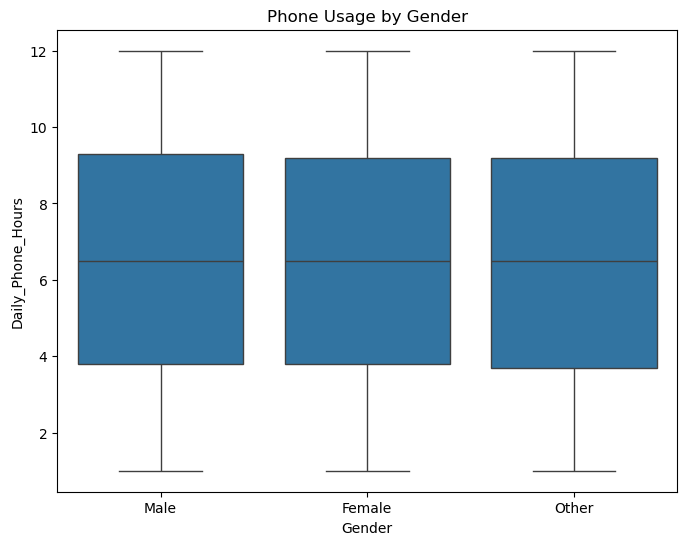

In [44]:
# Box plot comparison
plt.figure(figsize=(8,6))
sns.boxplot(x='Gender', y='Daily_Phone_Hours', data=smartphone_df)
plt.title('Phone Usage by Gender')
sns.set_style('darkgrid');

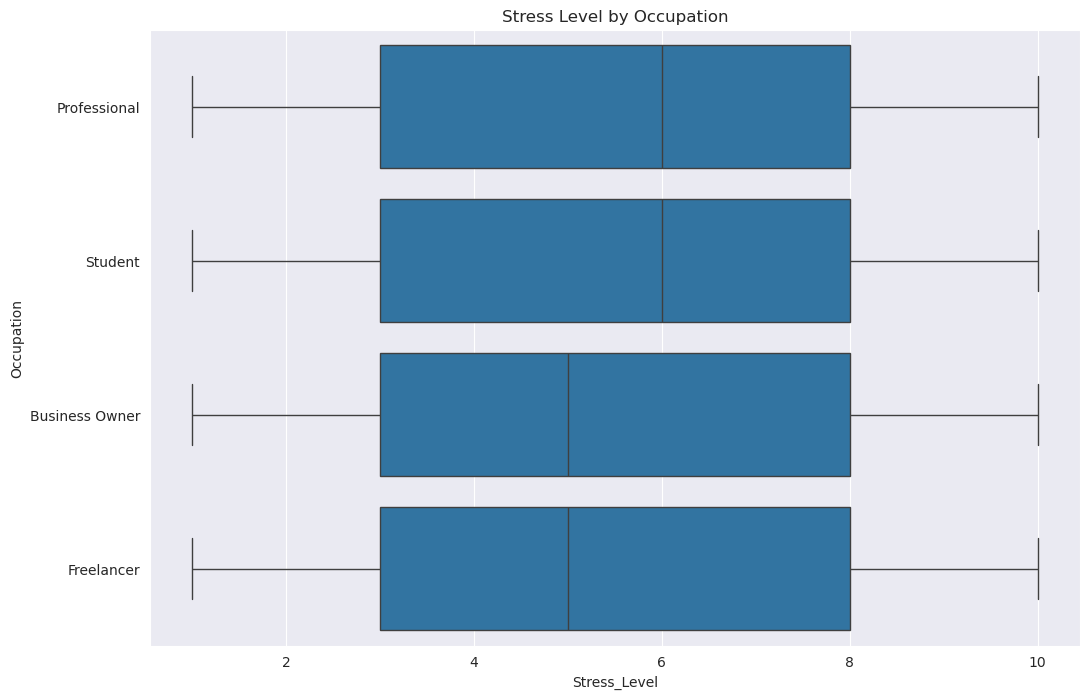

In [49]:
plt.figure(figsize=(12,8))
sns.boxplot(x='Stress_Level', y='Occupation', data=smartphone_df)
plt.title('Stress Level by Occupation');

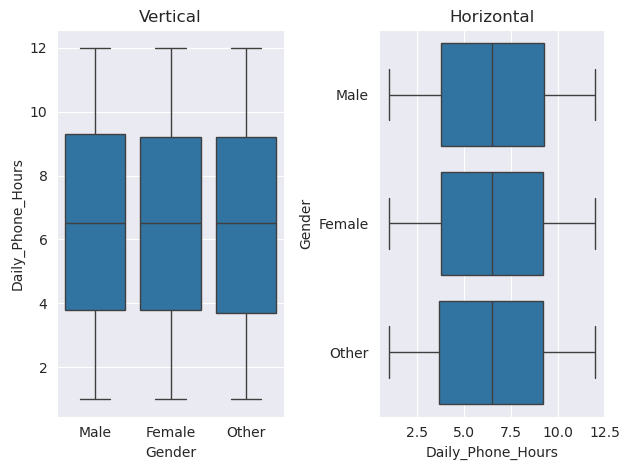

In [48]:
# Vertical boxplot (default)
plt.subplot(1,2,1)
sns.boxplot(x='Gender', y='Daily_Phone_Hours', data=smartphone_df)
plt.title('Vertical')

# Horizontal boxplot (swap x and y)
plt.subplot(1,2,2)
sns.boxplot(x='Daily_Phone_Hours', y='Gender', data=smartphone_df)
plt.title('Horizontal')

plt.tight_layout()
plt.show()

## Q7: Social Media Hours vs Stress Level

In [50]:
smartphone_df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


In [53]:
stress_line = smartphone_df.groupby('Stress_Level')[['Social_Media_Hours', 'Daily_Phone_Hours']].mean()
type(stress_line)

pandas.core.frame.DataFrame

In [63]:
stress_social = smartphone_df.groupby('Stress_Level')['Social_Media_Hours'].mean()

In [54]:
stress_line

,Social_Media_Hours,Daily_Phone_Hours
Stress_Level,,
1,4.288745,6.490000
2,4.272835,6.466568
3,4.255899,6.553104
4,4.288093,6.538185
5,4.250294,6.570801
6,4.228014,6.504177
7,4.311149,6.459477
8,4.270959,6.596896
9,4.266173,6.473763


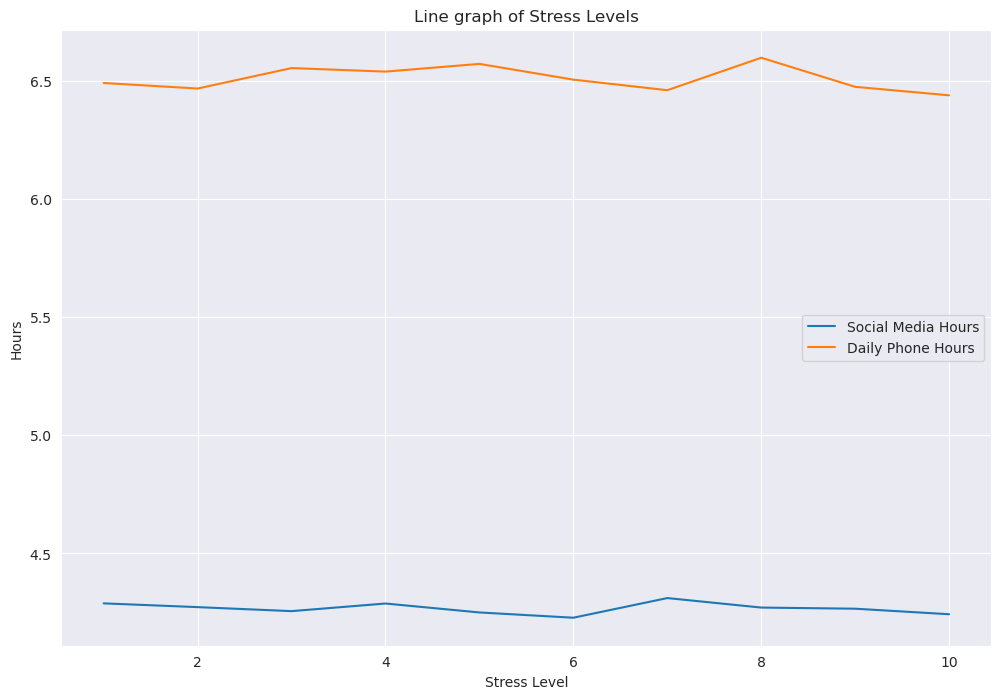

In [58]:
plt.figure(figsize=(12,8))
plt.plot(stress_line.index, stress_line['Social_Media_Hours'])
plt.plot(stress_line.index, stress_line['Daily_Phone_Hours'])

plt.xlabel('Stress Level')
plt.ylabel('Hours')

plt.title('Line graph of Stress Levels')
plt.legend(['Social Media Hours', 'Daily Phone Hours']);

<class 'pandas.core.series.Series'>
[4.28874494 4.27283511 4.25589938 4.28809279 4.25029435 4.22801418
 4.3111494  4.27095934 4.26617264 4.24275492]
Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype='int64', name='Stress_Level')


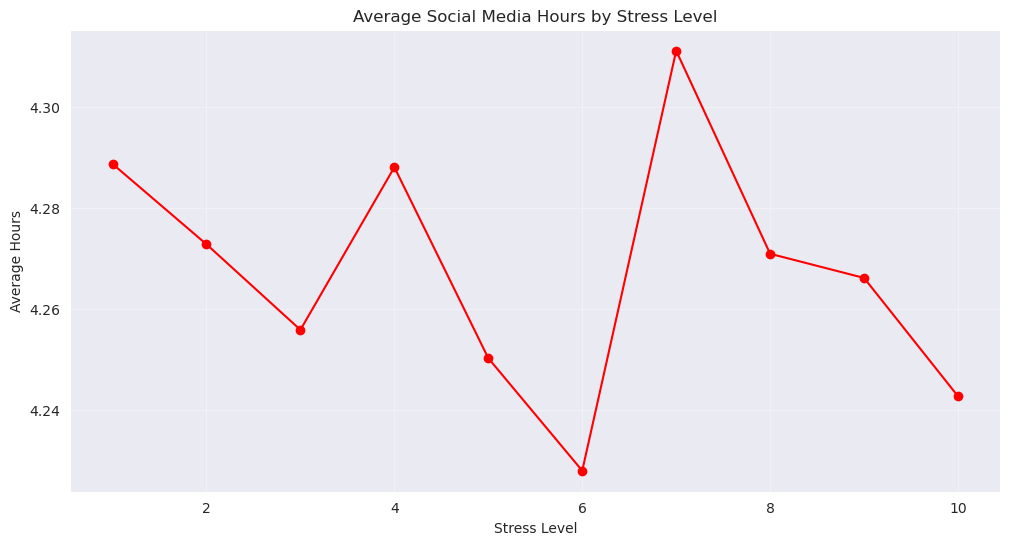

In [73]:
# Group by stress level and get average social media hours
stress_social = smartphone_df.groupby('Stress_Level')['Social_Media_Hours'].mean()
print(type(stress_social))
print(stress_social.values)
print(stress_social.index)

plt.figure(figsize=(12,6))
plt.plot(stress_social.index, stress_social.values, 'o-r') # use index and values

plt.xlabel('Stress Level')
plt.ylabel('Average Hours')

plt.title('Average Social Media Hours by Stress Level')
plt.grid(True, alpha=0.3);

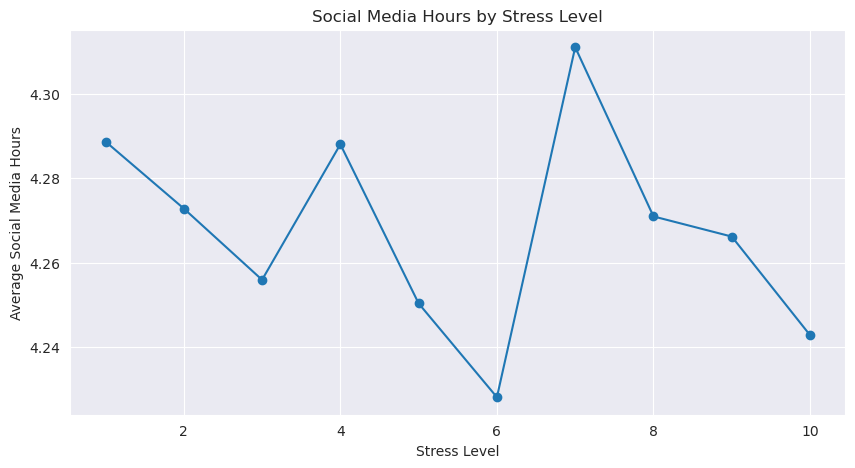

In [74]:
plt.figure(figsize=(10,5))
stress_social.plot(kind='line', marker='o')
plt.xlabel('Stress Level')
plt.ylabel('Average Social Media Hours')
plt.title('Social Media Hours by Stress Level')
plt.grid(True);

In [75]:
#  .corr() tells you: "When X goes up, does Y go up, down, or stay the same?"
corr = smartphone_df['Social_Media_Hours'].corr(smartphone_df['Stress_Level'])
print(f"Correlation: {corr:.2f}")

Correlation: -0.00


In [ ]:
smartphone_df.groupby('Occupation')['Caffeine_Intake_Cups'].

AttributeError: 'SeriesGroupBy' object has no attribute 'boxplot'

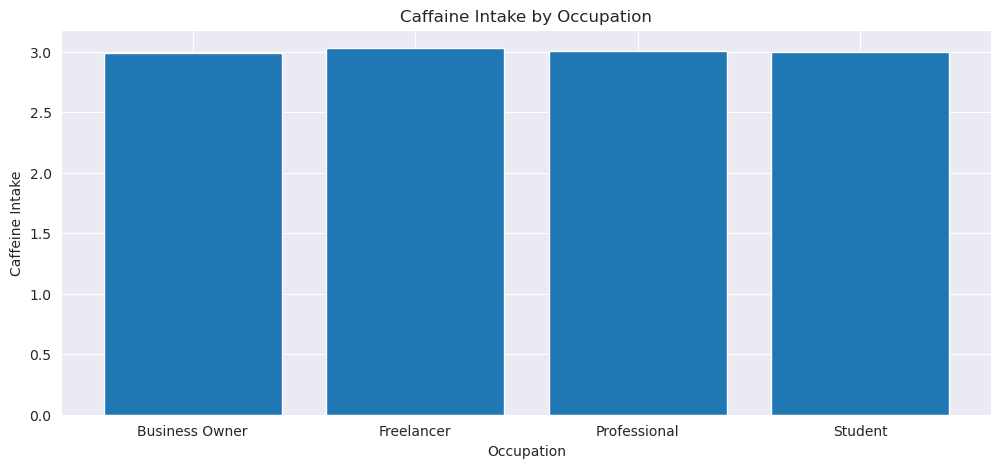

In [85]:
caffeine_intake_occ = smartphone_df.groupby('Occupation')['Caffeine_Intake_Cups'].mean()

plt.figure(figsize=(12,5))
plt.bar(caffeine_intake_occ.index, caffeine_intake_occ.values)

plt.xlabel('Occupation')
plt.ylabel('Caffeine Intake')

plt.title('Caffaine Intake by Occupation')
plt.show()

# PART 4: Multiple Variable Analysis
## Q8: Phone usage across occupations

In [86]:
occupation_usage = smartphone_df.groupby('Occupation')['Daily_Phone_Hours'].mean().sort_values()
occupation_usage

Occupation
Professional      6.489294
Student           6.491052
Freelancer        6.514675
Business Owner    6.541825
Name: Daily_Phone_Hours, dtype: float64

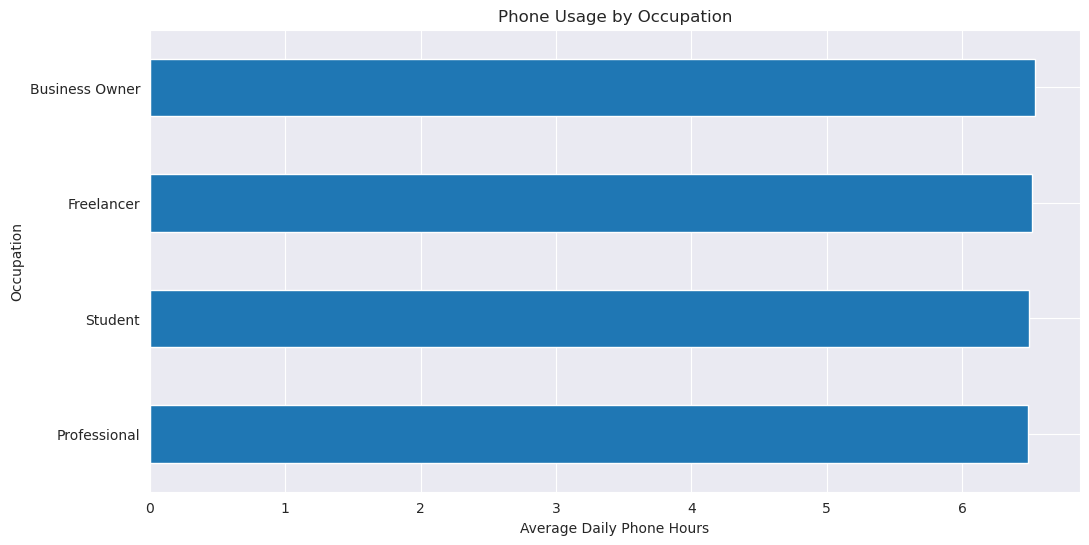

In [87]:
plt.figure(figsize=(12,6))
occupation_usage.plot(kind='barh')
plt.xlabel('Average Daily Phone Hours')
plt.title('Phone Usage by Occupation')
plt.show()

## Q9: Device type comparison

In [88]:
device_metrics = smartphone_df.groupby('Device_Type')[['Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score']].mean()
device_metrics

,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score
Device_Type,,,
Android,6.530494,4.267456,5.534370
iOS,6.487600,4.267043,5.472953


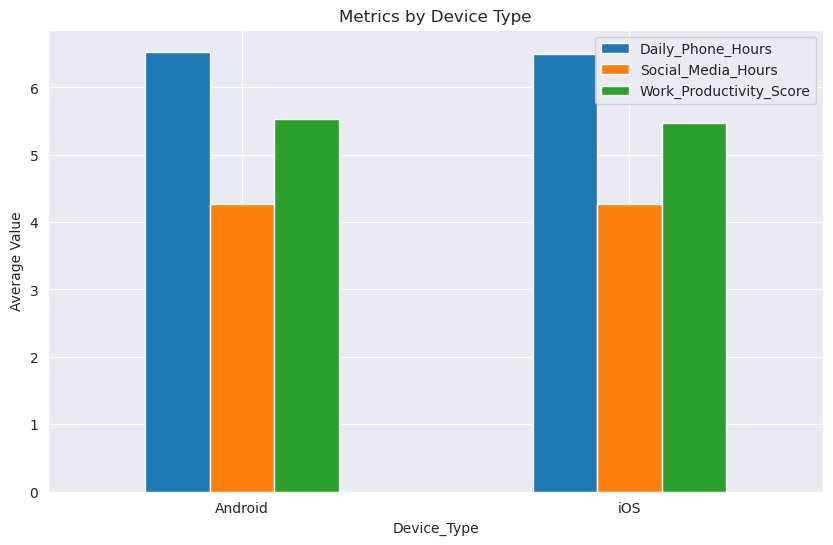

In [89]:
# Bar chart comparison
device_metrics.plot(kind='bar', figsize=(10,6))
plt.title('Metrics by Device Type')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.show()

# PART 5: Hypothesis Testing Questions
## Q10: Does caffeine intake affect sleep?

In [90]:
# Compare sleep hours by caffein intake
low_caffein = smartphone_df[smartphone_df['Caffeine_Intake_Cups'] <= 2]['Sleep_Hours'].mean()
high_caffein = smartphone_df[smartphone_df['Caffeine_Intake_Cups'] >= 4]['Sleep_Hours'].mean()

print(f"Low caffeine (<=2 cups): {low_caffein:.2f} hours sleep")
print(f"High caffeine (>=4 cups): {high_caffein:.2f} hours sleep")

Low caffeine (<=2 cups): 6.49 hours sleep
High caffeine (>=4 cups): 6.50 hours sleep


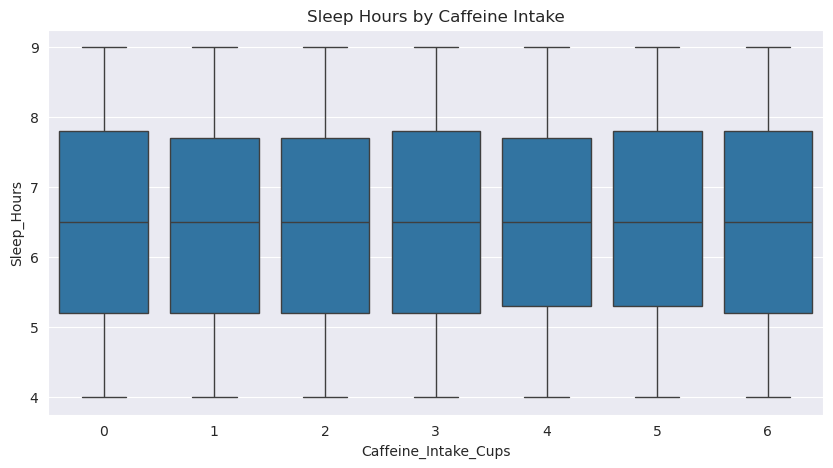

In [93]:
# Visualize
plt.figure(figsize=(10,5))
sns.boxplot(x='Caffeine_Intake_Cups', y='Sleep_Hours', data=smartphone_df)
plt.title('Sleep Hours by Caffeine Intake');

## Q11: Weekend vs weekday screen time

In [ ]:
smartphone_df.head()

In [94]:
smartphone_df['Weekend_Screen_Time_Hours'].mean()

np.float64(8.006844)

In [95]:
avg_weekday = smartphone_df['Daily_Phone_Hours'].mean()
avg_weekend = smartphone_df['Weekend_Screen_Time_Hours'].mean()

print(f"Average weekday usage: {avg_weekday:.2f} hours")
print(f"Average weekend usage: {avg_weekend:.2f} hours")
print(f"Difference: {avg_weekend - avg_weekday:.2f} hours")

Average weekday usage: 6.51 hours
Average weekend usage: 8.01 hours
Difference: 1.50 hours


This means that people use their phones more on the Weekend than on Weekdays.

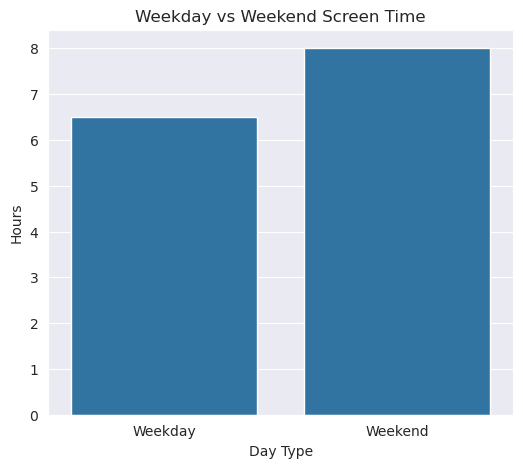

In [96]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'Day Type': ['Weekday', 'Weekend'],
    'Hours': [avg_weekday, avg_weekend]
})

plt.figure(figsize=(6,5))
sns.barplot(x='Day Type', y='Hours', data=comparison)
plt.title('Weekday vs Weekend Screen Time');

In [97]:
smartphone_df.columns

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type',
       'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score',
       'Sleep_Hours', 'Stress_Level', 'App_Usage_Count',
       'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'],
      dtype='object')

<Axes: xlabel='Stress_Level', ylabel='App_Usage_Count'>

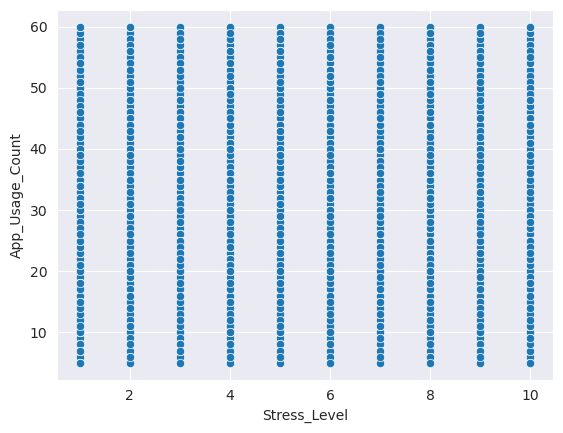

In [99]:
sns.scatterplot(x=smartphone_df.Stress_Level, y=smartphone_df.App_Usage_Count)

# PART 6: Advanced Analysis Questions
## Q12: Create a productivity score by age group

In [100]:
smartphone_df['Age_Group'] = pd.cut(smartphone_df['Age'], bins=[0, 25, 35, 50, 100], labels=['18-25', '26-35', '36-50', '50+'])

productivity_by_age = smartphone_df.groupby('Age_Group')['Work_Productivity_Score'].mean()
productivity_by_age

/tmp/ipykernel_382/2551910653.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  productivity_by_age = smartphone_df.groupby('Age_Group')['Work_Productivity_Score'].mean()


Age_Group
18-25    5.514801
26-35    5.512435
36-50    5.510700
50+      5.475904
Name: Work_Productivity_Score, dtype: float64

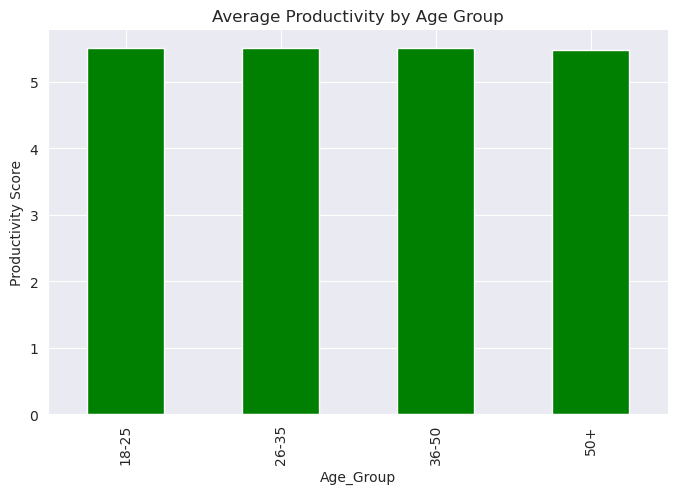

In [101]:
plt.figure(figsize=(8,5))
productivity_by_age.plot(kind='bar', color='green')
plt.title('Average Productivity by Age Group')
plt.ylabel('Productivity Score');

In [102]:
smartphone_df[['Age_Group', 'Age']]

,Age_Group,Age
0,50+,58
1,18-25,25
2,18-25,19
3,26-35,35
4,26-35,33
...,...,...
49995,36-50,44
49996,36-50,42
49997,26-35,27
49998,36-50,41


## Q13: Identify high-risk users (high stress + low sleep)

In [ ]:
# Define high-risk: stress > 7 AND sleep < 6
high_risk = smartphone_df[(smartphone_df['Stress_Level'] > 7) & (smartphone_df['Sleep_Hours'] < 6)]

print(f"Number of high-rist users: {len(high_risk)}")
print(f"Percentage: {len(high_risk)/len(smartphone_df)*100:.2f}%")

print("\nHigh-risk users profile:")
print(high_risk[['Age', 'Gender', 'Daily_Phone_Hours', 'Caffeine_Intake_Cups']])

# Practice Questions to Answer

1. What's the average daily phone usage by gender?

In [ ]:
smartphone_df.groupby('Gender')['Daily_Phone_Hours'].agg(['mean', 'median'])

In [ ]:
# Visualize
sns.boxplot(x='Gender', y='Daily_Phone_Hours', data=smartphone_df)
plt.title('Phone Usage Distribution by Gender')
plt.show()

2. Do older users have different phone habits than younger users?

In [ ]:
smartphone_df.groupby('Age_Group')[['Daily_Phone_Hours', 'Weekend_Screen_Time_Hours', 'Social_Media_Hours', 'Stress_Level']].mean()

3. Is there a relationship between app count and phone hours?

In [ ]:
smartphone_df[['App_Usage_Count', 'Daily_Phone_Hours']].mean()

4. Which Occupation has the highest stress level?

In [ ]:
smartphone_df.columns

In [ ]:
smartphone_df.groupby('Occupation')[['Sleep_Hours', 'Stress_Level']].mean()

5. Does device type affect productivity scores?

In [ ]:
smartphone_df.groupby('Device_Type')['Work_Productivity_Score'].mean()

6. What's the optimal caffeine intake for sleep quality?

7. How does social media usage vary by age group?

In [ ]:
smartphone_df.groupby('Age_Group')['Social_Media_Hours'].mean()

## 1. Check for missing values

In [ ]:
smartphone_df.isnull().sum()

## 2. Data Clearning and Preprocessing
Convert categorical columns to category type for efficiency:

In [ ]:
smartphone_df['Gender'] = smartphone_df['Gender'].astype('category')
smartphone_df['Occupation'] = smartphone_df['Occupation'].astype('category')
smartphone_df['Device_Type'] = smartphone_df['Device_Type'].astype('category')

In [ ]:
smartphone_df['Gender']

In [ ]:
smartphone_df['Gender'].dtype

Check for duplicates.

In [ ]:
print(f"Duplicates: {smartphone_df.duplicated().sum()}")

## 3. Export Basic Summary Statistics

In [ ]:
# Overall statistics
overall_stats = smartphone_df.describe(include='all').transpose()
overall_stats

In [ ]:
overall_stats.to_csv('overall_statistics.csv')

In [ ]:
overall_stats_df = pd.read_csv('overall_statistics.csv')
overall_stats_df

File: overall_statistics.csv contains count, mean, std, min, quartiles, max for numeric columns, and frequency info for categorical columns.

# 4. Univariate Analysis (Each Variable)
## 4.1 Distribution of Age

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(smartphone_df['Age'], bins=20, kde=True)
plt.title('Age Distribution of Users')
plt.show()

In [ ]:
smartphone_df['Age'].describe()

## 4.2 Gender Count

In [ ]:
gender_counts = smartphone_df['Gender'].value_counts()
print(gender_counts)

In [ ]:
gender_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Gender Distribution')
plt.ylabel('Count')
plt.show()
gender_counts.to_csv('gender_counts.csv')

## 4.3 Occupation Distribution

In [ ]:
occupation_count = smartphone_df['Occupation'].value_counts()
print(occupation_count)

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=occupation_count.index, y=occupation_count.values)
plt.xticks(rotation=45)
plt.title('Occupation Distribution')
plt.tight_layout()
plt.show()

## 4.4 Device Type

In [ ]:
device_counts = smartphone_df['Device_Type'].value_counts()
print(device_counts)

In [ ]:
plt.pie(device_counts, labels=device_counts.index, autopct='%1.1f%%')
plt.title('Device Type Share')
plt.show()

## 4.5 Daily Phone Hours

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(smartphone_df['Daily_Phone_Hours'], bins=30, kde=True)

plt.title('Daily Phone Hours Distribution')
plt.subplot(1,2,2)
sns.boxplot(y=smartphone_df['Daily_Phone_Hours'])
plt.title('Boxplot of Phone Hours')
plt.tight_layout();

In [ ]:
sns.histplot(smartphone_df['App_Usage_Count'], bins=10)

Export numeric distributions (mean, median, mode) for all continous variables:

In [ ]:
numeric_cols = [
    'Age', 'Daily_Phone_Hours', 'Social_Media_Hours', 
    'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level',
    'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'
]
stats_df = smartphone_df[numeric_cols].agg(['mean', 'median', 'std', 'min', 'max']).T
stats_df

# 5. Bivariate Analysis - Real-World Questions
## Q1: Does phone usage differ between genders?

In [ ]:
# Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='Gender', y='Daily_Phone_Hours', data=smartphone_df)
plt.title('Phone Usage Distribution by Gender')
plt.show()

In [ ]:
# Statistical test (t-test)
male = smartphone_df[smartphone_df['Gender']=='Male']['Daily_Phone_Hours'].mean()
female = smartphone_df[smartphone_df['Gender']=='Female']['Daily_Phone_Hours'].mean()

print(f"Average Phone Usage for Male: {male:.2f}")
print(f"Average Phone Usage for Females: {female:.2f}")

In [ ]:
plt.title('Caffeine Cup Intake')
plt.hist(smartphone_df['Caffeine_Intake_Cups']);

In [ ]:
smartphone_df.columns

In [ ]:
plt.title('New Histogram')
sns.histplot(x='Daily_Phone_Hours', data=smartphone_df);

In [ ]:
plt.title('Histogram of Daily Hours')
plt.hist(smartphone_df['Daily_Phone_Hours']);
# use sns.histplot instead

We can create different data frames from different Genders and analys them

In [ ]:
male_df = smartphone_df[smartphone_df.Gender == 'Male']
female_df = smartphone_df[smartphone_df.Gender == 'Female']
other_df = smartphone_df[smartphone_df.Gender == 'Other']

In [ ]:
plt.hist(male_df.App_Usage_Count, alpha=0.4)
plt.hist(female_df.App_Usage_Count, alpha=0.4)

plt.legend(['Male', 'Female']);

In [ ]:
stress_level = smartphone_df.Stress_Level
male_sleep = male_df.Sleep_Hours
female_sleep = female_df.Sleep_Hours

## Q6: Weekend vs weekday screen time

In [ ]:
# Already have both columns; compare averages
avg_weekday = smartphone_df['Daily_Phone_Hours'].mean()
avg_weekend = smartphone_df['Weekend_Screen_Time_Hours'].mean()

print(f"Average weekday: {avg_weekday:.2f} hrs, weekend: {avg_weekend:.2f} hrs.")

In [ ]:
male_daily_hours = smartphone_df[smartphone_df['Gender'] == 'Male']['Daily_Phone_Hours']
female_daily_hours = smartphone_df[smartphone_df['Gender'] == 'Female']['Daily_Phone_Hours']

plt.figure(figsize=(10,6))
plt.hist(male_daily_hours, alpha=0.5, bins=20, color='blue', label='Male')
plt.hist(female_daily_hours, alpha=0.5, bins=20, color='red', label='Female')
plt.xlabel('Daily Phone Hours')
plt.ylabel('Frequency')
plt.title('Phone Usage by Gender')
plt.legend();

## Q7: Device type and usage patterns

In [ ]:
smartphone_df.groupby('Device_Type', observed=False)['Stress_Level'].agg(['mean', 'std', 'median'])

In [ ]:
device_agg = smartphone_df.groupby('Device_Type', observed=False)[['Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score']].mean()
device_agg.to_csv('device_aggregates.csv')
print(device_agg)

In [ ]:
device_agg.plot(kind='bar', figsize=(10,6))
plt.title('Average Metrics by Device Type')
plt.ylabel('Average Value')
plt.xticks(rotation=0);

## Q8: Which occupation has highest stress?

In [ ]:
occ_stress = smartphone_df.groupby('Occupation', observed=False)['Stress_Level'].mean()
print(occ_stress)

In [ ]:
occ_stress.plot(kind='pie')
plt.title('Pie Chart of Stress Levels by Occupation')
plt.figure(figsize=(10,6));

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=occ_stress.index, y=occ_stress.values)
plt.ylabel('Stress Levels')
plt.xlabel('Occupations')
plt.title('Average Stress Level by Occupation');

## Q9: App usage count vs daily phone hours

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='App_Usage_Count', y='Daily_Phone_Hours', data=smartphone_df, alpha=0.6)
sns.regplot(x='App_Usage_Count', y='Daily_Phone_Hours', data=smartphone_df, scatter=False, color='red')
plt.title('Apps Count vs Phone Hours');